### Q1

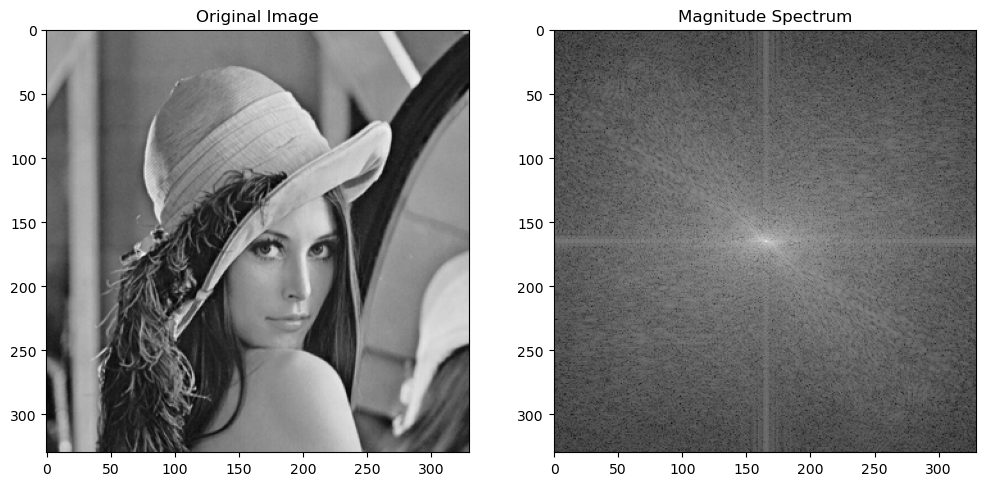

In [2]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, fftshift, ifft2, ifftshift

img = cv2.imread(r"E:\SRM\Digital Image\Lab 6 - 14th October\test_image.png", 0)

f_transform = fft2(img)
f_transform_shifted = fftshift(f_transform)
magnitude_spectrum = np.log(np.abs(f_transform_shifted) + 1)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1), plt.imshow(img, cmap='gray'), plt.title("Original Image")
plt.subplot(1,2,2), plt.imshow(magnitude_spectrum, cmap='gray'), plt.title("Magnitude Spectrum")
plt.show()


In [4]:

# Ideal Low-Pass Filter
def ideal_low_pass_filter(shape, D0):
    M, N = shape
    U, V = np.meshgrid(np.arange(M), np.arange(N), indexing='ij')
    D = np.sqrt((U - M/2)**2 + (V - N/2)**2)
    H = np.where(D <= D0, 1, 0).astype(np.float32)
    return H

# Butterworth Low-Pass Filter
def butterworth_low_pass_filter(shape, D0, n):
    M, N = shape
    U, V = np.meshgrid(np.arange(M), np.arange(N), indexing='ij')
    D = np.sqrt((U - M/2)**2 + (V - N/2)**2)
    H = 1 / (1 + (D / D0) ** (2 * n)).astype(np.float32)
    return H

# Gaussian Low-Pass Filter
def gaussian_low_pass_filter(shape, D0):
    M, N = shape
    U, V = np.meshgrid(np.arange(M), np.arange(N), indexing='ij')
    D = np.sqrt((U - M/2)**2 + (V - N/2)**2)
    H = np.exp(-(D ** 2) / (2 * (D0 ** 2))).astype(np.float32)
    return H


In [6]:

# Apply a filter and perform inverse Fourier Transform
def apply_filter_and_inverse(f_transform_shifted, H):
    Gshift = f_transform_shifted * H
    G = ifftshift(Gshift)
    g = np.abs(ifft2(G))
    return g

# Plotting function to compare original and filtered image
def plot_images(original, filtered, title):
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(original, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(filtered, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()


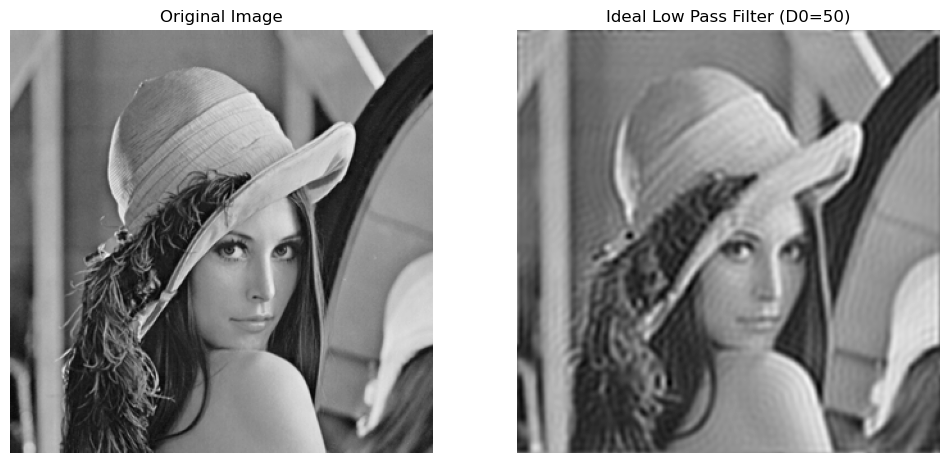

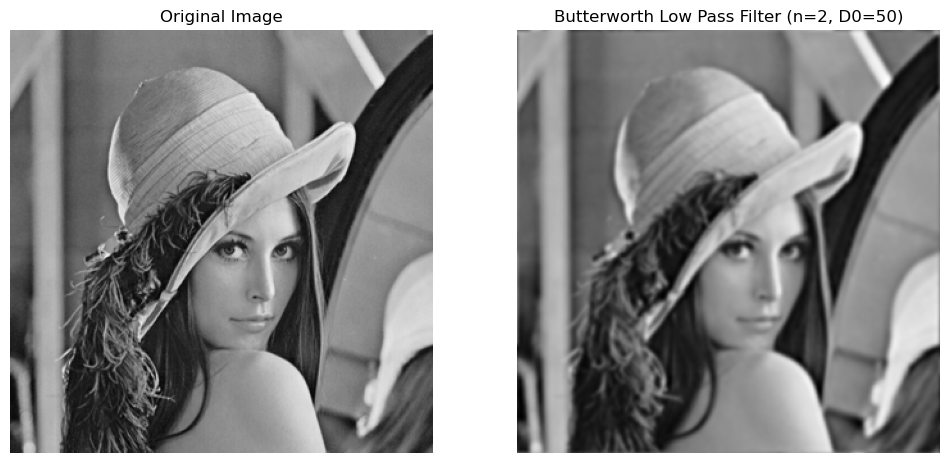

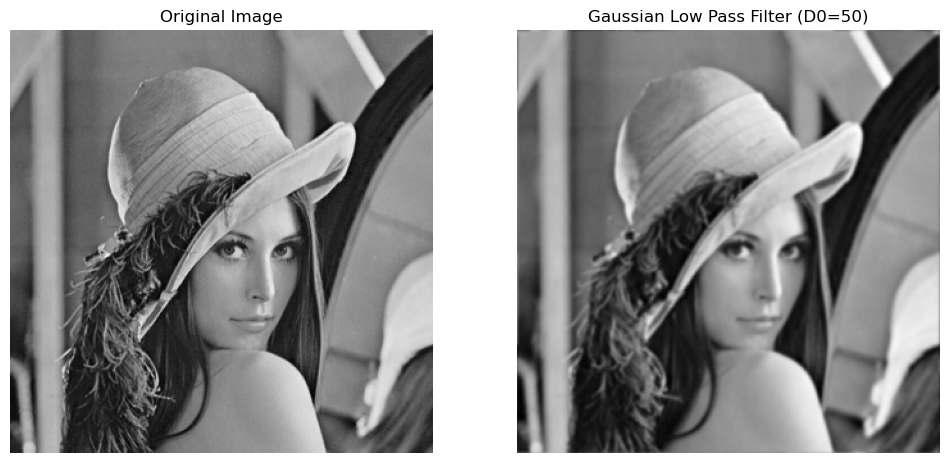

In [8]:

# Set cutoff frequency
cutoff = 50

# Ideal Low-Pass Filter
H_ideal = ideal_low_pass_filter(img.shape, cutoff)
ideal_filtered_img = apply_filter_and_inverse(f_transform_shifted, H_ideal)
plot_images(img, ideal_filtered_img, f"Ideal Low Pass Filter (D0={cutoff})")

# Butterworth Low-Pass Filter (Order 2)
n = 2
H_butterworth = butterworth_low_pass_filter(img.shape, cutoff, n)
butterworth_filtered_img = apply_filter_and_inverse(f_transform_shifted, H_butterworth)
plot_images(img, butterworth_filtered_img, f"Butterworth Low Pass Filter (n={n}, D0={cutoff})")

# Gaussian Low-Pass Filter
H_gaussian = gaussian_low_pass_filter(img.shape, cutoff)
gaussian_filtered_img = apply_filter_and_inverse(f_transform_shifted, H_gaussian)
plot_images(img, gaussian_filtered_img, f"Gaussian Low Pass Filter (D0={cutoff})")


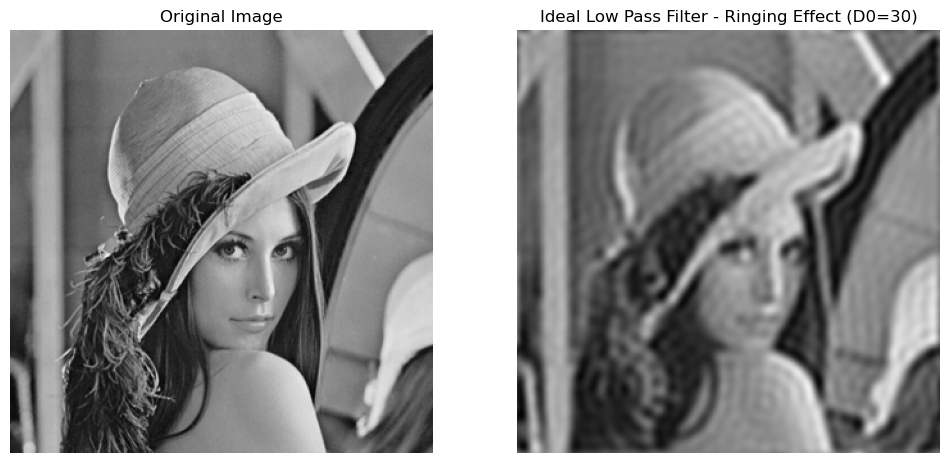

In [10]:

# Apply Ideal Low-Pass Filter with ringing effect demonstration
cutoff = 30  # Sharp cut-off frequency to highlight ringing
H_ideal_ringing = ideal_low_pass_filter(img.shape, cutoff)
ideal_filtered_img_ringing = apply_filter_and_inverse(f_transform_shifted, H_ideal_ringing)
plot_images(img, ideal_filtered_img_ringing, f"Ideal Low Pass Filter - Ringing Effect (D0={cutoff})")


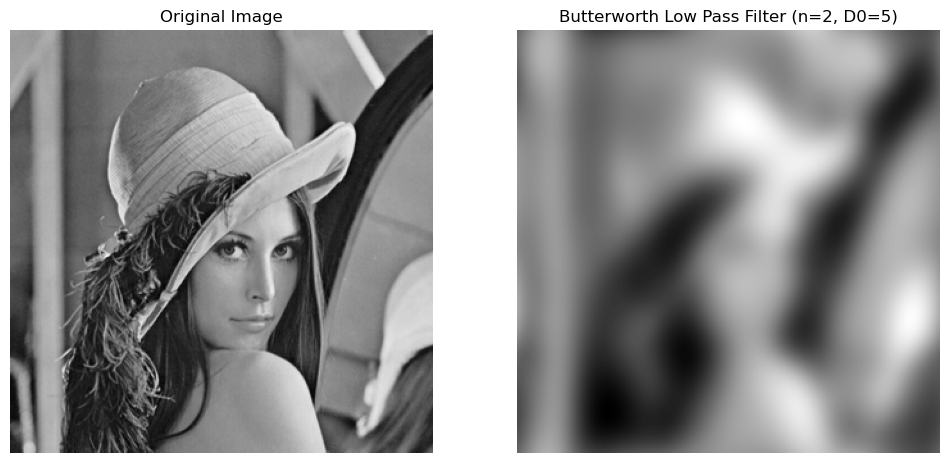

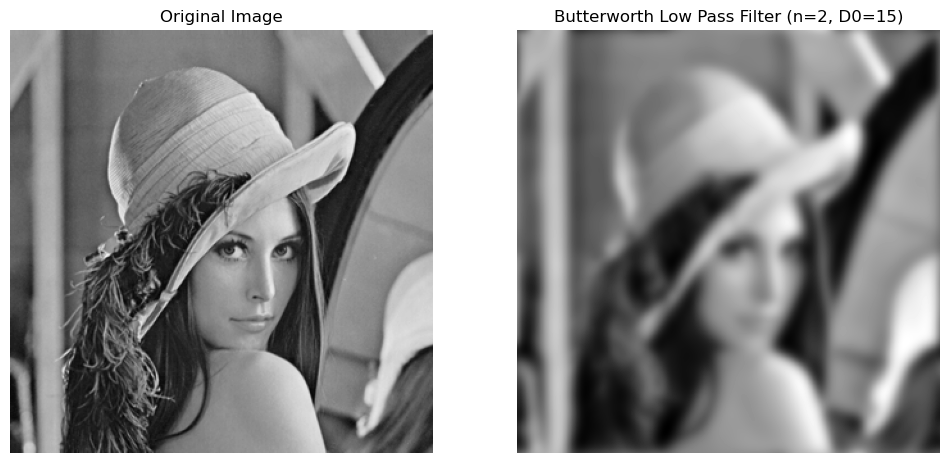

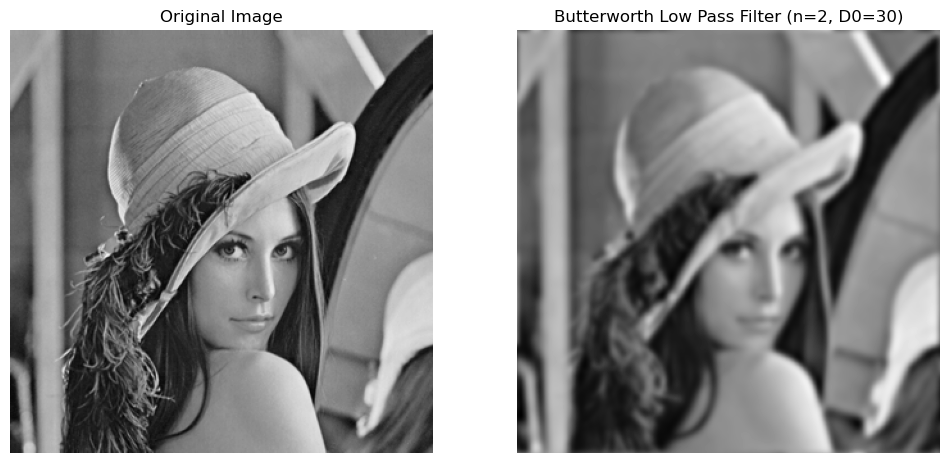

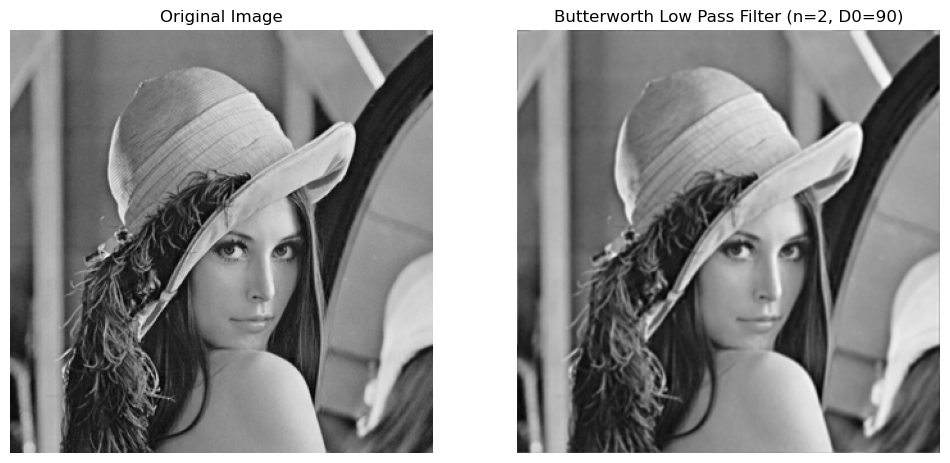

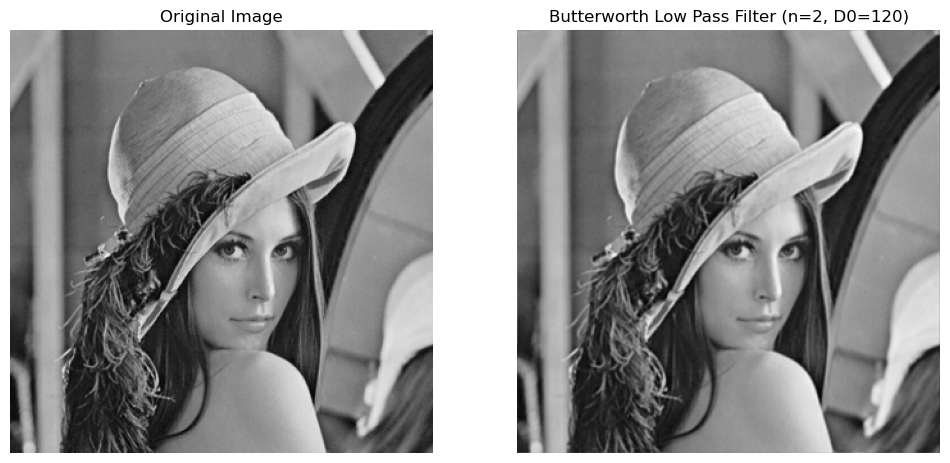

In [12]:

# Compare Butterworth Low-Pass Filters for different cutoff frequencies
cutoffs = [5, 15, 30, 90, 120]
n = 2  # Fixed order of the filter

for c in cutoffs:
    H_butterworth = butterworth_low_pass_filter(img.shape, c, n)
    butterworth_filtered_img = apply_filter_and_inverse(f_transform_shifted, H_butterworth)
    plot_images(img, butterworth_filtered_img, f"Butterworth Low Pass Filter (n={n}, D0={c})")


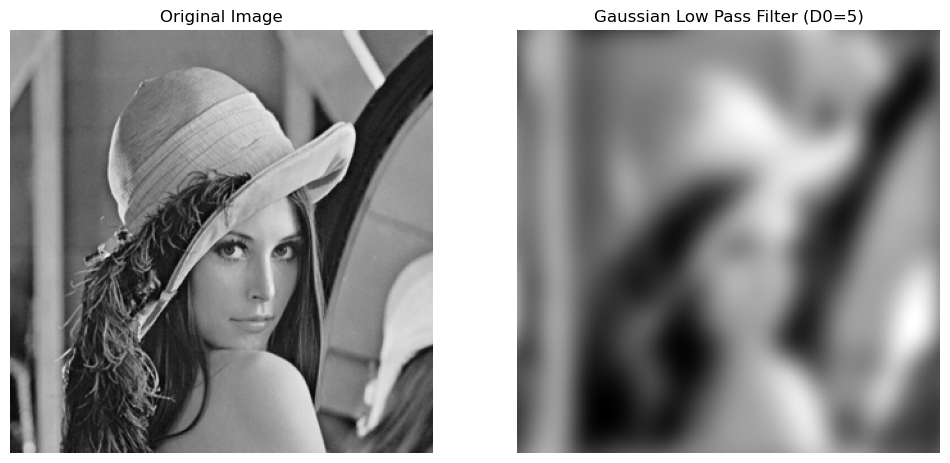

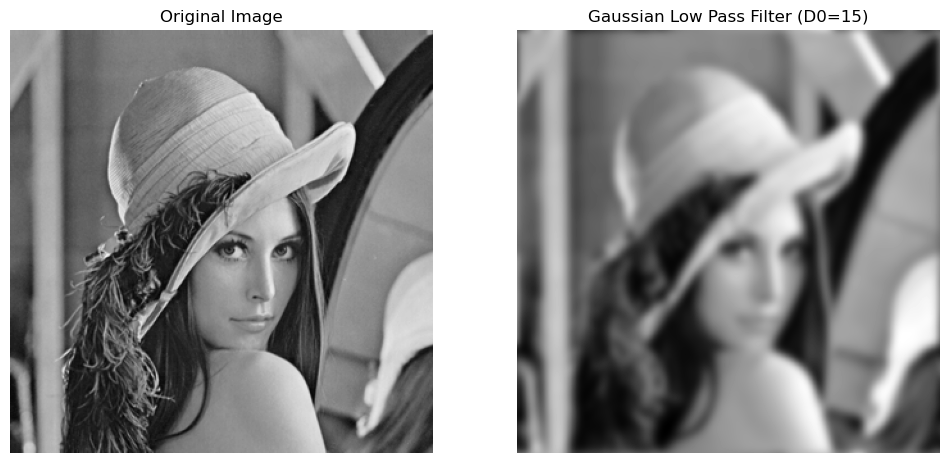

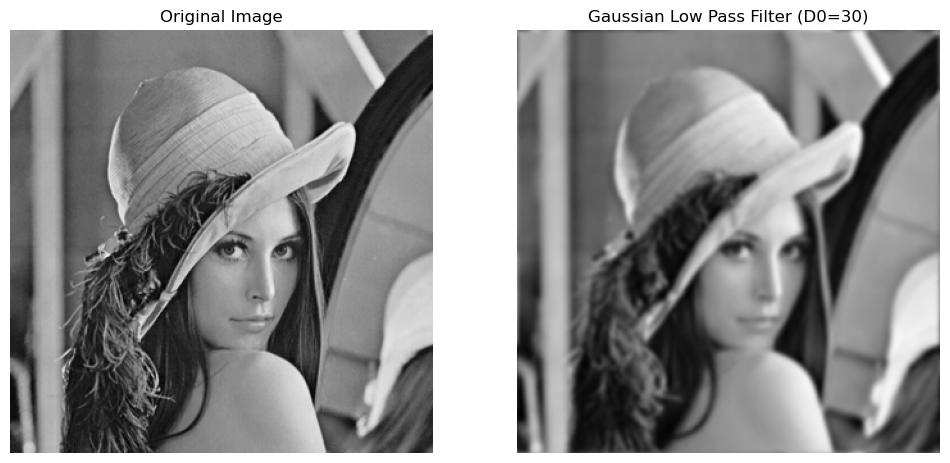

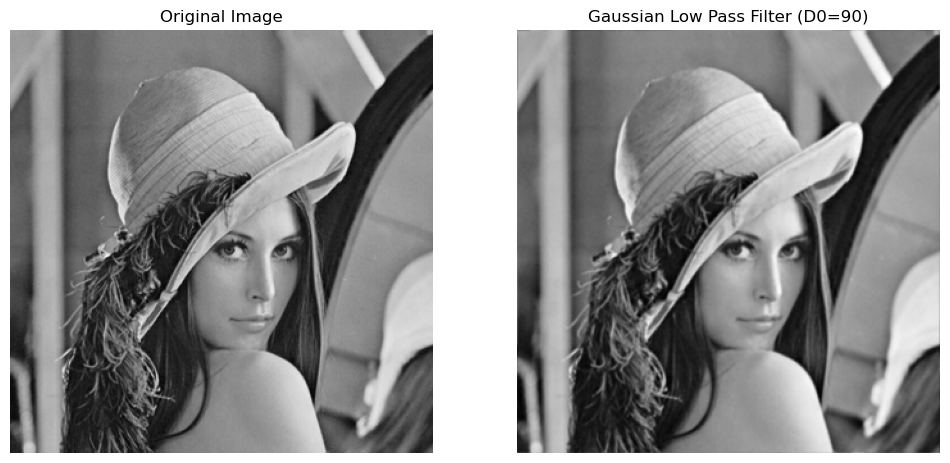

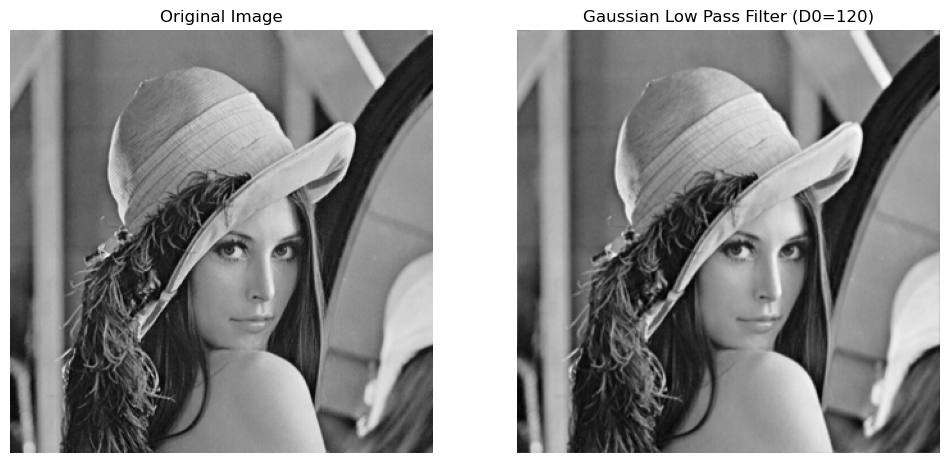

In [14]:

# Compare Gaussian Low-Pass Filters for different cutoff frequencies
cutoffs = [5, 15, 30, 90, 120]

for c in cutoffs:
    H_gaussian = gaussian_low_pass_filter(img.shape, c)
    gaussian_filtered_img = apply_filter_and_inverse(f_transform_shifted, H_gaussian)
    plot_images(img, gaussian_filtered_img, f"Gaussian Low Pass Filter (D0={c})")
